In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"E:/RetailPulse_Project/data/cleaned/cleaned_online_retail_I.csv")

In [3]:
df.shape

(392693, 8)

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392693 entries, 0 to 392692
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392693 non-null  int64  
 1   StockCode    392693 non-null  str    
 2   Description  392693 non-null  str    
 3   Quantity     392693 non-null  int64  
 4   InvoiceDate  392693 non-null  str    
 5   UnitPrice    392693 non-null  float64
 6   CustomerID   392693 non-null  float64
 7   Country      392693 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 24.0 MB


In [6]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392693 entries, 0 to 392692
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392693 non-null  int64         
 1   StockCode    392693 non-null  str           
 2   Description  392693 non-null  str           
 3   Quantity     392693 non-null  int64         
 4   InvoiceDate  392693 non-null  datetime64[us]
 5   UnitPrice    392693 non-null  float64       
 6   CustomerID   392693 non-null  float64       
 7   Country      392693 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(2), str(3)
memory usage: 24.0 MB


In [8]:
df.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID
count,392693.000000,392693.000000,392693,392693.000000,392693.000000
mean,560590.928514,13.119671,2011-07-10 19:13:41.156272,3.125952,15287.837224
min,536365.000000,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,549234.000000,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,561874.000000,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,572061.000000,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,581587.000000,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,13087.089985,180.492603,NaN,22.241820,1713.542421


In [9]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["MonthName"] = df["InvoiceDate"].dt.month_name()
df["Day"] = df["InvoiceDate"].dt.day
df["Weekday"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

In [13]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Unique Customers:", df["CustomerID"].nunique())
print("Unique Products:", df["StockCode"].nunique())
print("Unique Countries:", df["Country"].nunique())
print("Unique Orders:", df["InvoiceNo"].nunique())

Rows: 392693
Columns: 16
Unique Customers: 4338
Unique Products: 3665
Unique Countries: 37
Unique Orders: 18532


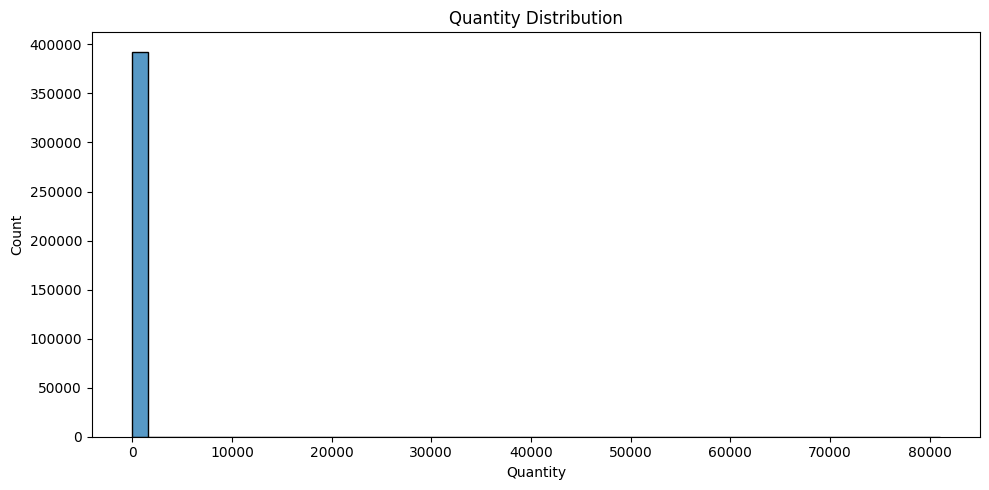

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df["Quantity"],bins = 50)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.tight_layout()

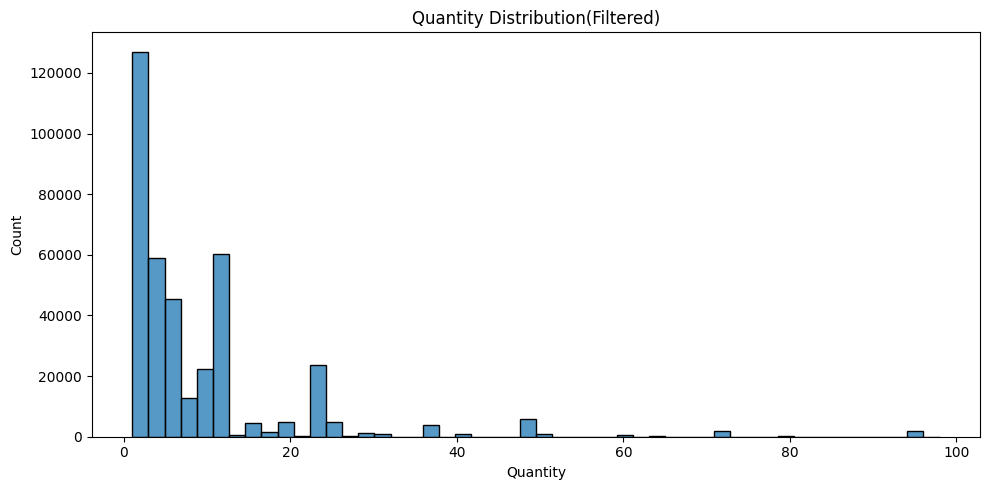

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df[df["Quantity"] < 100]["Quantity"],bins = 50)
plt.title("Quantity Distribution(Filtered)")
plt.xlabel("Quantity")
plt.tight_layout()

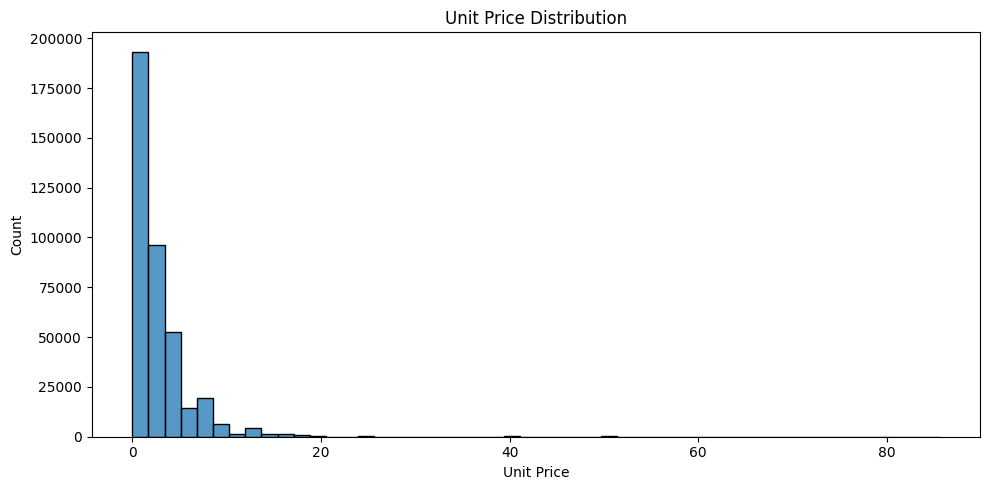

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df[df["UnitPrice"]<100]["UnitPrice"],bins = 50)
plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.tight_layout()

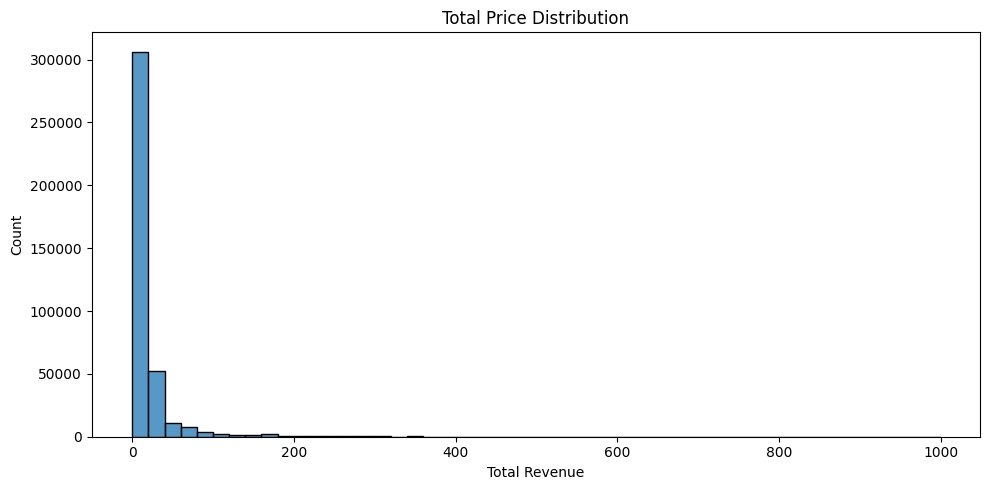

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(df[df["TotalPrice"] < 1000]["TotalPrice"],bins = 50)
plt.title("Total Price Distribution")
plt.xlabel("Total Revenue")
plt.tight_layout()

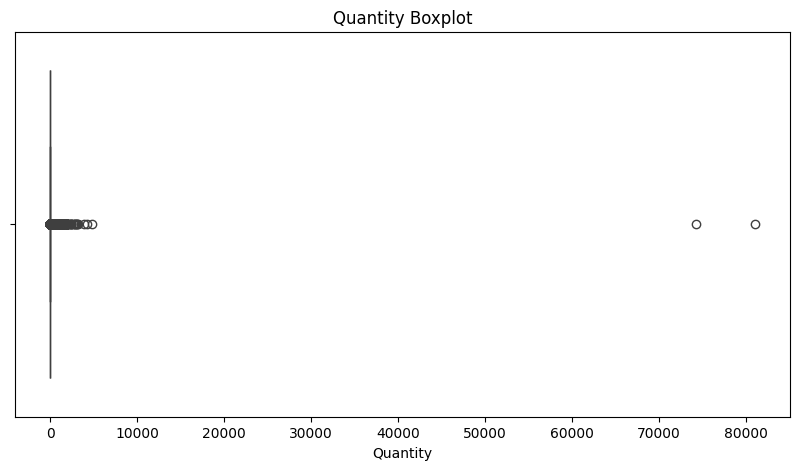

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["Quantity"])
plt.title("Quantity Boxplot")
plt.show()

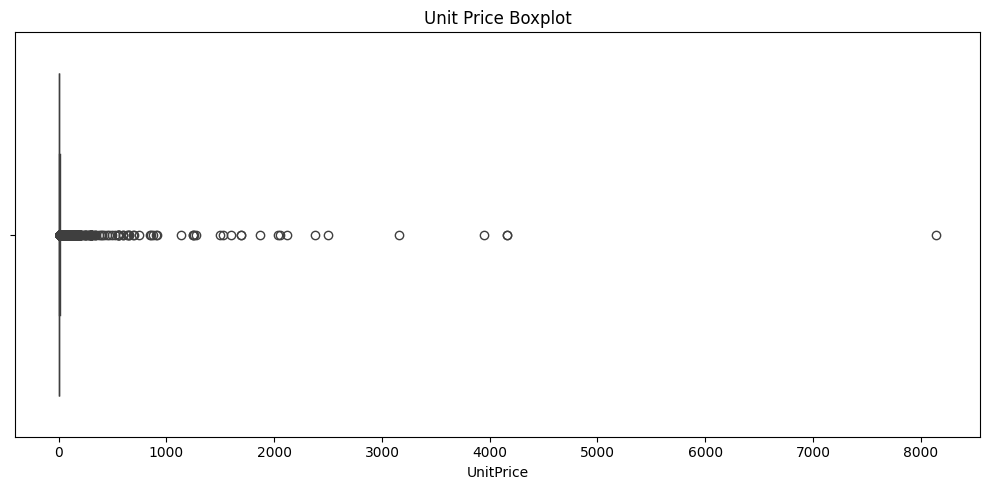

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(x = df["UnitPrice"])
plt.title("Unit Price Boxplot")
plt.tight_layout()

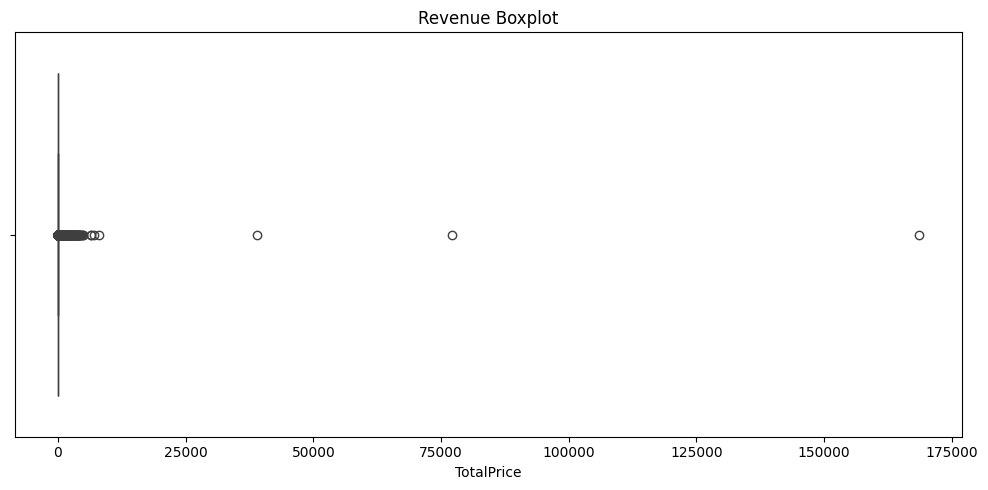

In [21]:
plt.figure(figsize = (10,5))
sns.boxplot(x = df["TotalPrice"])
plt.title("Revenue Boxplot")
plt.tight_layout()

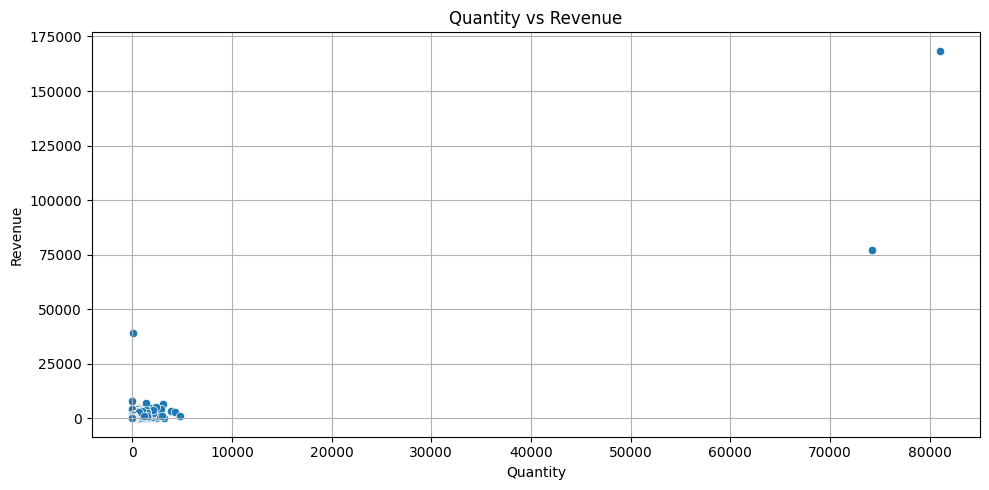

In [23]:
plt.figure(figsize=(10,5))
sns.scatterplot(x = "Quantity",y = "TotalPrice",data = df)
plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.tight_layout()
plt.grid(True)

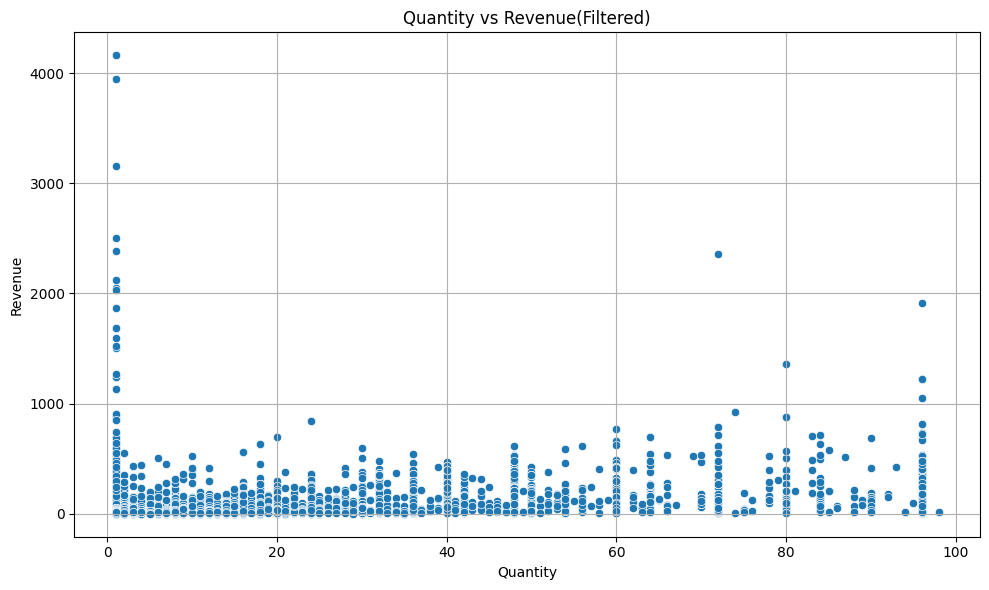

In [25]:
plt.figure(figsize=(10,6))

filtered_df = df[
    (df["Quantity"] < 100) &
    (df["TotalPrice"] < 5000)]

sns.scatterplot(
    x = "Quantity",
    y = "TotalPrice",
    data = filtered_df)

plt.title("Quantity vs Revenue(Filtered)")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.tight_layout()
plt.grid(True)

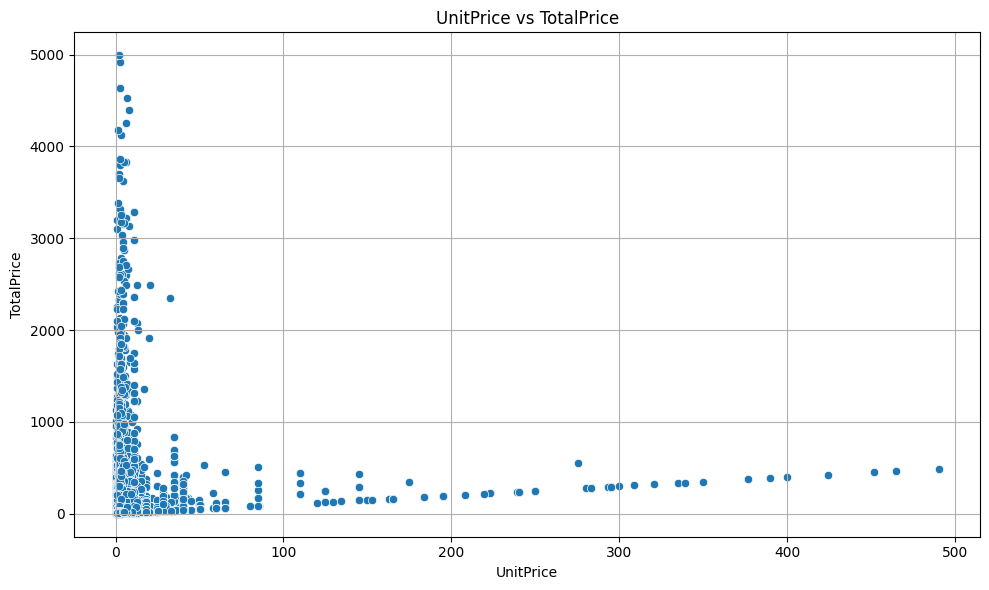

In [28]:
plt.figure(figsize = (10,6))

filtered_df = df[
    (df["UnitPrice"] < 500) &
    (df["TotalPrice"] < 5000)]

sns.scatterplot(
    x = "UnitPrice",
    y = "TotalPrice",
    data = filtered_df)

plt.title("UnitPrice vs TotalPrice")
plt.xlabel("UnitPrice")
plt.ylabel("TotalPrice")
plt.tight_layout()
plt.grid(True)

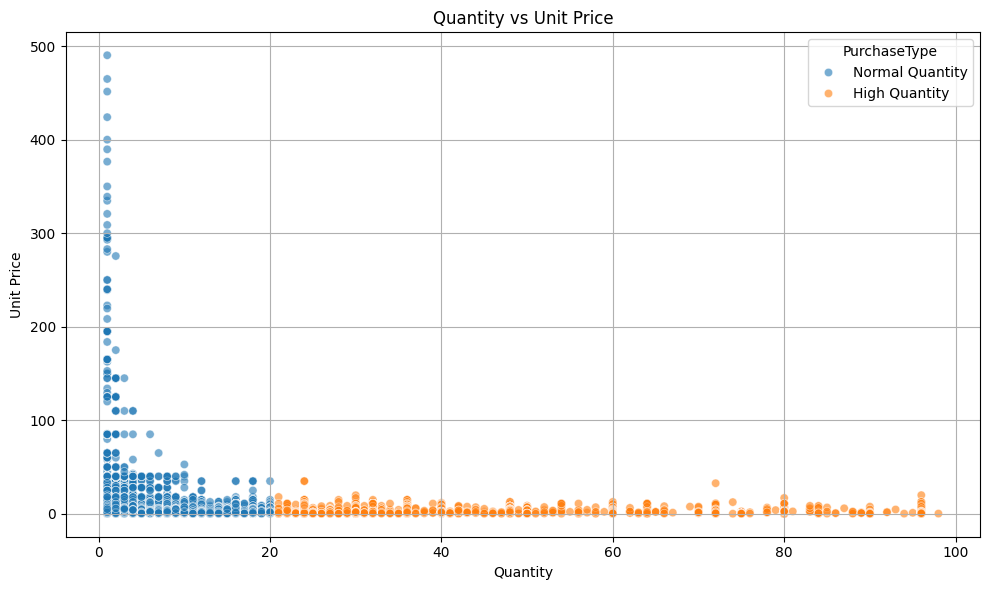

In [31]:
plt.figure(figsize=(10,6))

filtered_df = df[
    (df["Quantity"] < 100) &
    (df["UnitPrice"] < 500)
].copy()

filtered_df["PurchaseType"] = np.where(
    filtered_df["Quantity"] > 20,
    "High Quantity",
    "Normal Quantity"
)

sns.scatterplot(
    x="Quantity",
    y="UnitPrice",
    data=filtered_df,
    hue="PurchaseType",
    alpha=0.6
)

plt.title("Quantity vs Unit Price")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.tight_layout()
plt.grid(True)

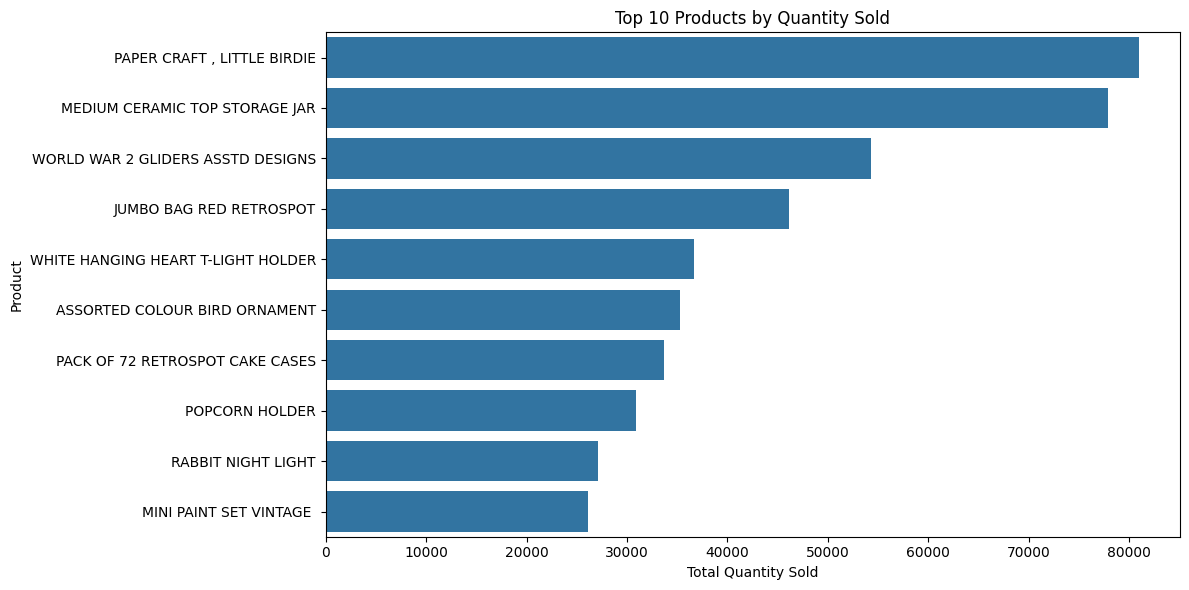

In [34]:
tag_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending = False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x = tag_products.values,
    y = tag_products.index
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()

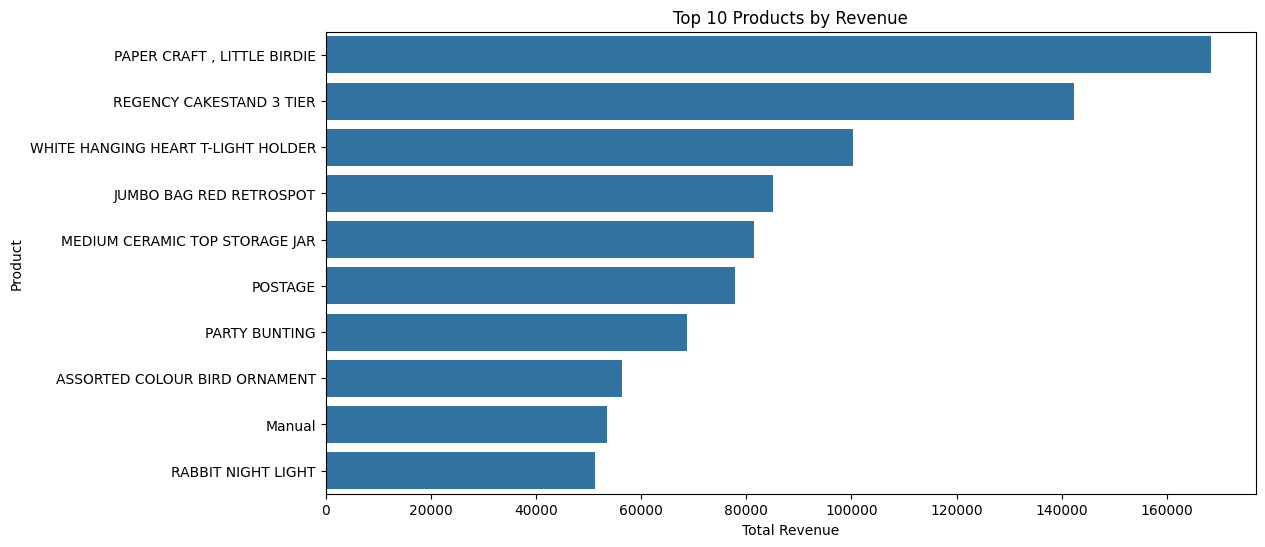

In [35]:
top_revenue_products = (
    df.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_revenue_products.values,
    y=top_revenue_products.index
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.show()

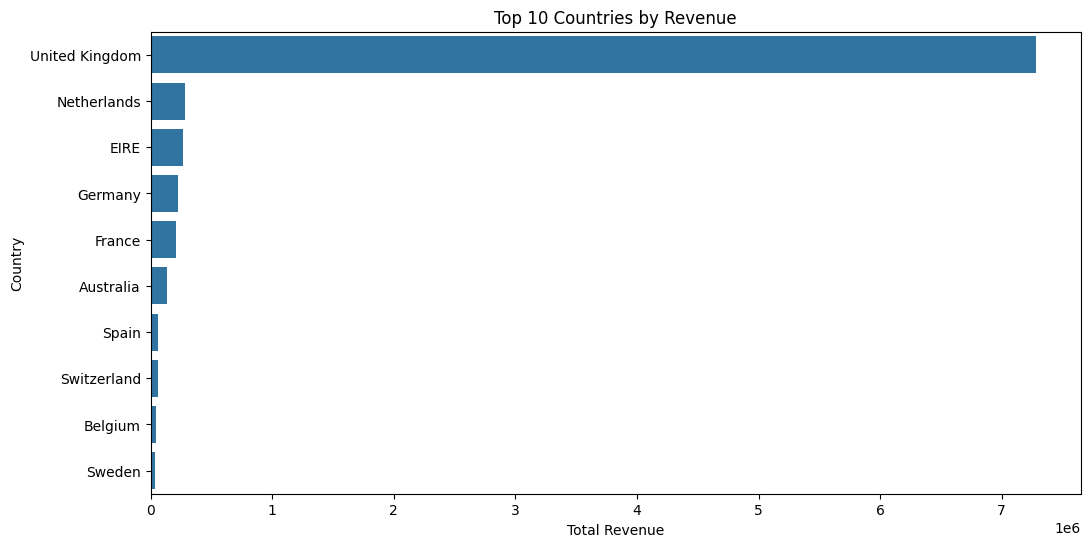

In [36]:
top_countries = (
    df.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.show()

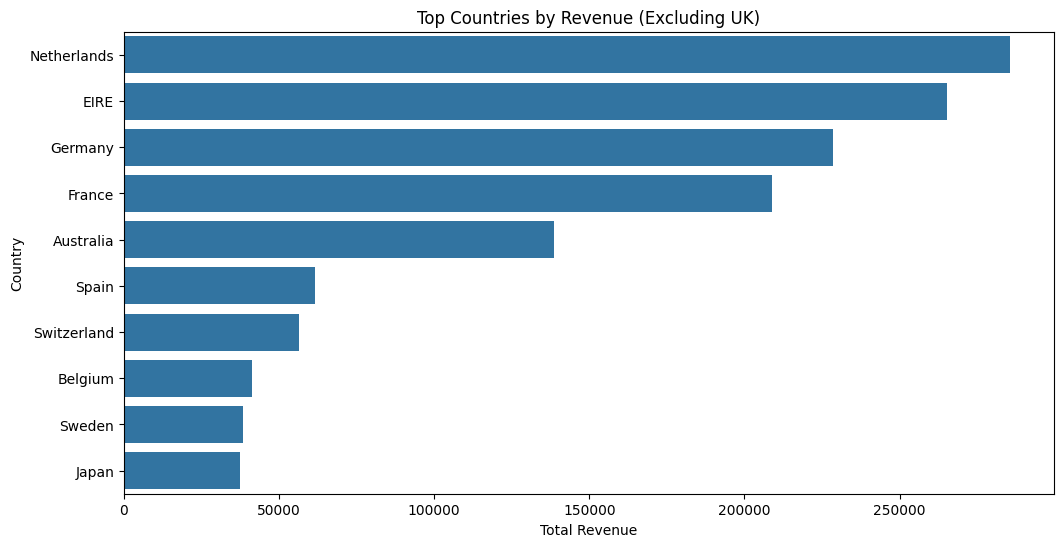

In [37]:
country_revenue_no_uk = (
    df[df["Country"] != "United Kingdom"]
    .groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_revenue_no_uk.values,
    y=country_revenue_no_uk.index
)

plt.title("Top Countries by Revenue (Excluding UK)")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.show()

In [38]:
montly_sales = (
    df.groupby("MonthName")["TotalPrice"]
    .sum()
)

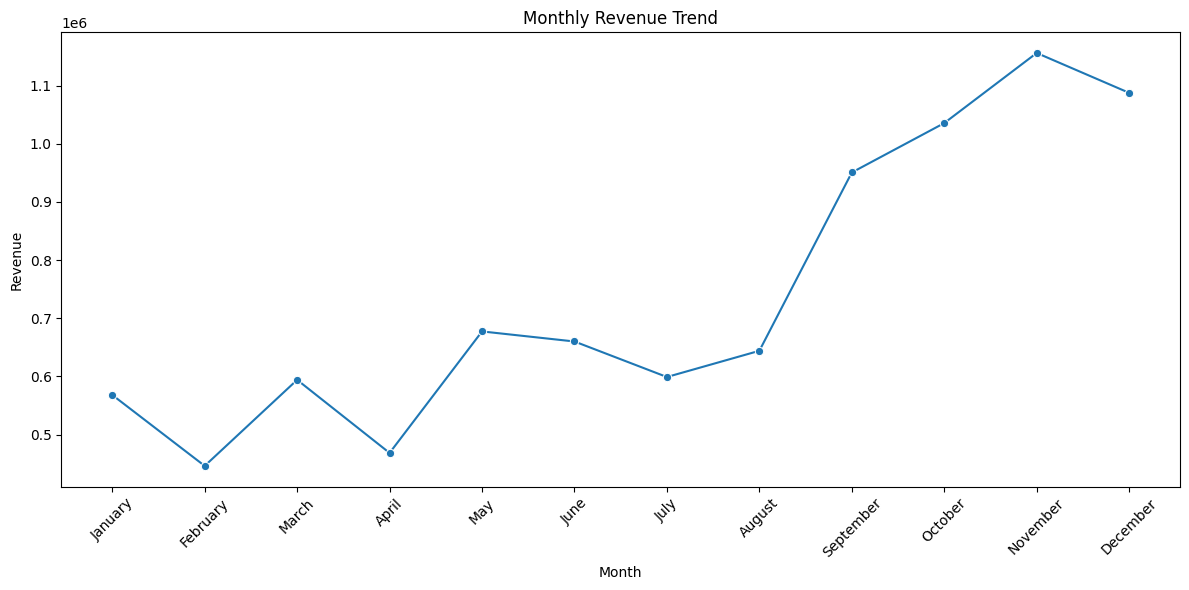

In [39]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

montly_sales = (
    df.groupby("MonthName")["TotalPrice"]
    .sum()
    .reindex(month_order)
)

plt.figure(figsize=(12,6))

sns.lineplot(
    x = montly_sales.index,
    y = montly_sales.values,
    marker = "o"
)

plt.xticks(rotation = 45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()

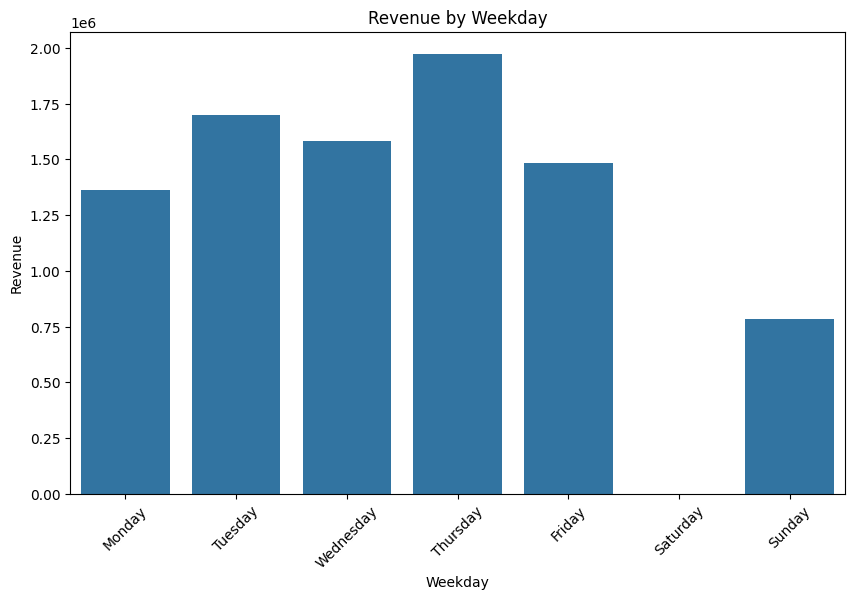

In [40]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = (
    df.groupby("Weekday")["TotalPrice"]
    .sum()
    .reindex(weekday_order)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values
)

plt.title("Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

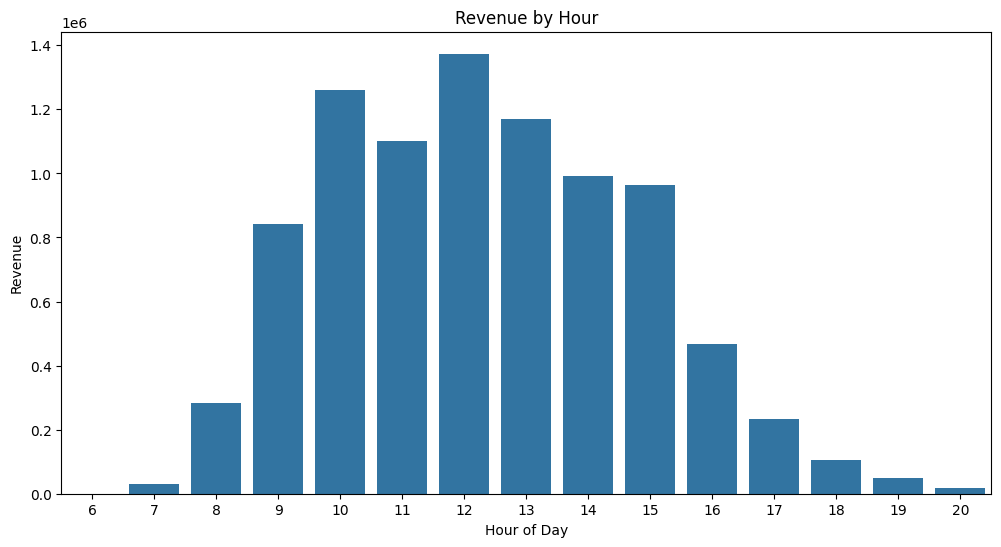

In [41]:
hourly_sales = (
    df.groupby("Hour")["TotalPrice"]
    .sum()
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=hourly_sales.index,
    y=hourly_sales.values
)

plt.title("Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")
plt.show()

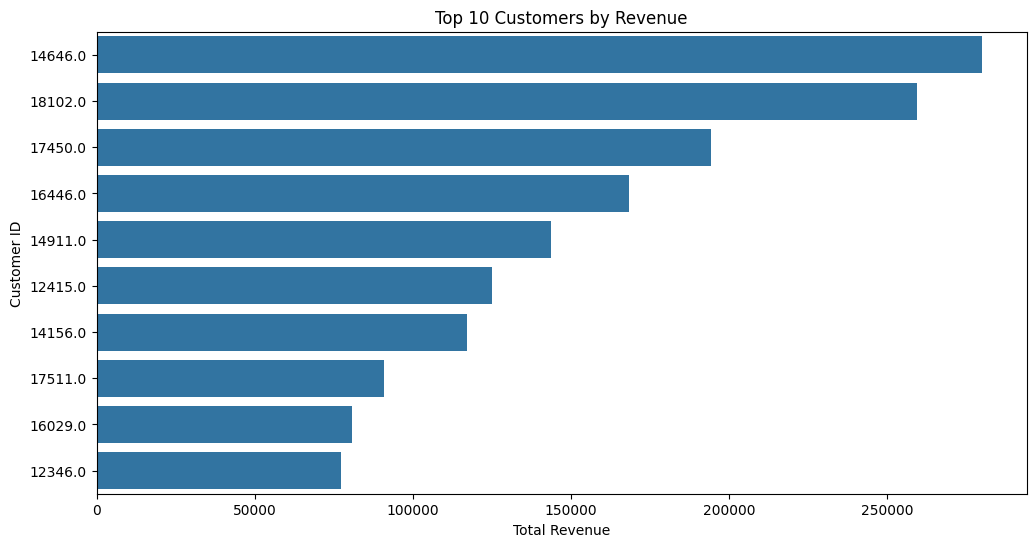

In [42]:
top_customers = (
    df.groupby("CustomerID")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index.astype(str)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")
plt.show()

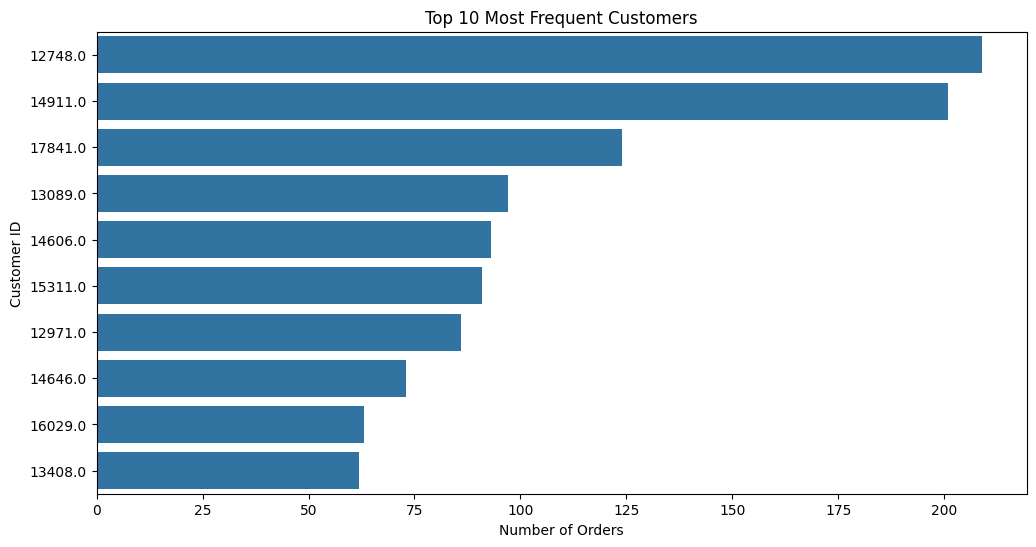

In [43]:
top_frequent_customers = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_frequent_customers.values,
    y=top_frequent_customers.index.astype(str)
)

plt.title("Top 10 Most Frequent Customers")
plt.xlabel("Number of Orders")
plt.ylabel("Customer ID")
plt.show()

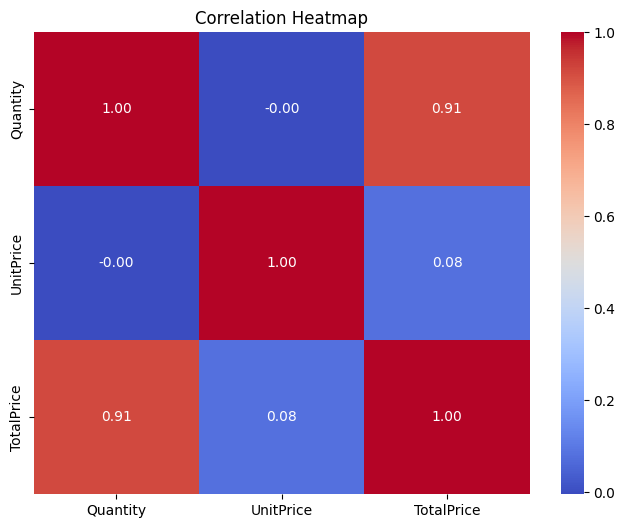

In [44]:
corr = df[["Quantity", "UnitPrice", "TotalPrice"]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


In [45]:
df.to_csv(r"E:\RetailPulse_Project\data\cleaned\online_retail_eda_ready_small.csv", index=False)